In [ ]:
!pip install -q kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version:      {np.__version__}")
print(f"Pandas version:     {pd.__version__}")

TensorFlow version: 2.20.0
NumPy version:      2.0.2
Pandas version:     2.2.2


In [ ]:
import kagglehub

# Download the Pima Indians Diabetes dataset from Kaggle
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
print("Dataset downloaded to:", path)

import os
# Find the CSV file in the downloaded path
csv_file = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith(".csv"):
            csv_file = os.path.join(root, f)
            break

print("CSV file found:", csv_file)

# Load dataset
df = pd.read_csv(csv_file)

# Column descriptions
column_info = {
    "Pregnancies": "Number of times pregnant",
    "Glucose": "Plasma glucose concentration (2h oral glucose tolerance test)",
    "BloodPressure": "Diastolic blood pressure (mm Hg)",
    "SkinThickness": "Triceps skin fold thickness (mm)",
    "Insulin": "2-Hour serum insulin (mu U/ml)",
    "BMI": "Body mass index (weight in kg / height in m²)",
    "DiabetesPedigreeFunction": "Diabetes pedigree function (genetic score)",
    "Age": "Age in years",
    "Outcome": "Target — 1 = Diabetes, 0 = No Diabetes",
}

print("\n📋 Column Descriptions:")
for col, desc in column_info.items():
    print(f"  • {col}: {desc}")


Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Dataset downloaded to: /kaggle/input/pima-indians-diabetes-database
CSV file found: /kaggle/input/pima-indians-diabetes-database/diabetes.csv

📋 Column Descriptions:
  • Pregnancies: Number of times pregnant
  • Glucose: Plasma glucose concentration (2h oral glucose tolerance test)
  • BloodPressure: Diastolic blood pressure (mm Hg)
  • SkinThickness: Triceps skin fold thickness (mm)
  • Insulin: 2-Hour serum insulin (mu U/ml)
  • BMI: Body mass index (weight in kg / height in m²)
  • DiabetesPedigreeFunction: Diabetes pedigree function (genetic score)
  • Age: Age in years
  • Outcome: Target — 1 = Diabetes, 0 = No Diabetes


In [ ]:
print("=" * 60)
print("📊  EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Shape & first rows
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print(df.head(10))

print("\n─── Statistical Summary ───")
print(df.describe().round(2))

print("\n─── Data Types & Null Counts ───")
print(df.info())

print("\n─── Missing Values ───")
print(df.isnull().sum())

# Target distribution
print("\n─── Target Distribution ───")
print(df["Outcome"].value_counts())
print(f"\nDiabetes ratio: {df['Outcome'].mean():.2%}")


📊  EXPLORATORY DATA ANALYSIS

Dataset shape: 768 rows × 9 columns

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           10      115              0              0        0  35.3   
8            2      197             70             45      543  30.5   
9            8      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2       

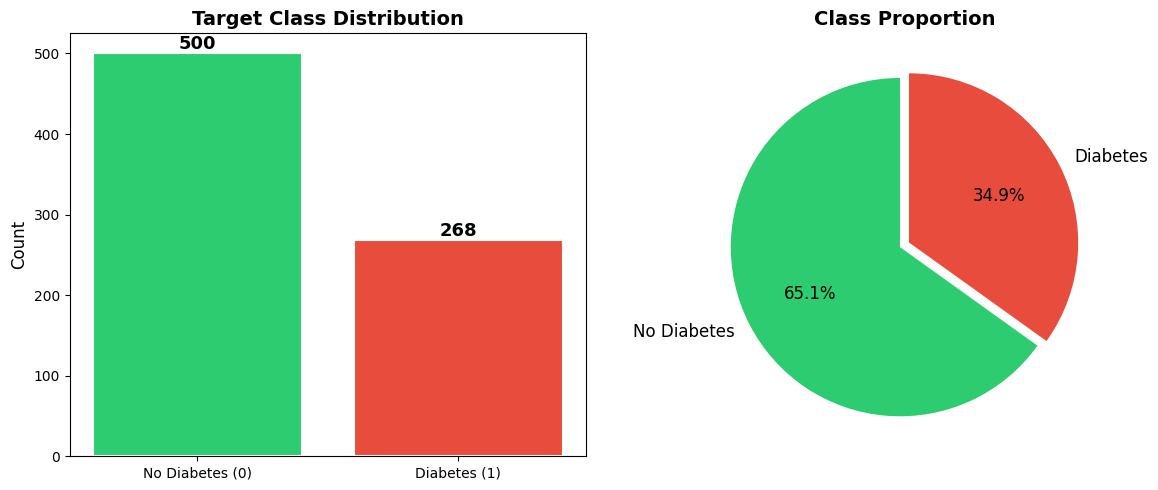

In [ ]:
# %% ─── CELL 4: Visualize Target Distribution ────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
colors = ["#2ecc71", "#e74c3c"]
ax1 = axes[0]
counts = df["Outcome"].value_counts()
ax1.bar(["No Diabetes (0)", "Diabetes (1)"], counts.values, color=colors,
        edgecolor="white", linewidth=1.5)
ax1.set_title("Target Class Distribution", fontsize=14, fontweight="bold")
ax1.set_ylabel("Count", fontsize=12)
for i, v in enumerate(counts.values):
    ax1.text(i, v + 5, str(v), ha="center", fontsize=13, fontweight="bold")

# Pie chart
ax2 = axes[1]
ax2.pie(counts.values, labels=["No Diabetes", "Diabetes"],
        autopct="%1.1f%%", colors=colors, startangle=90,
        explode=(0.03, 0.03), textprops={"fontsize": 12})
ax2.set_title("Class Proportion", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

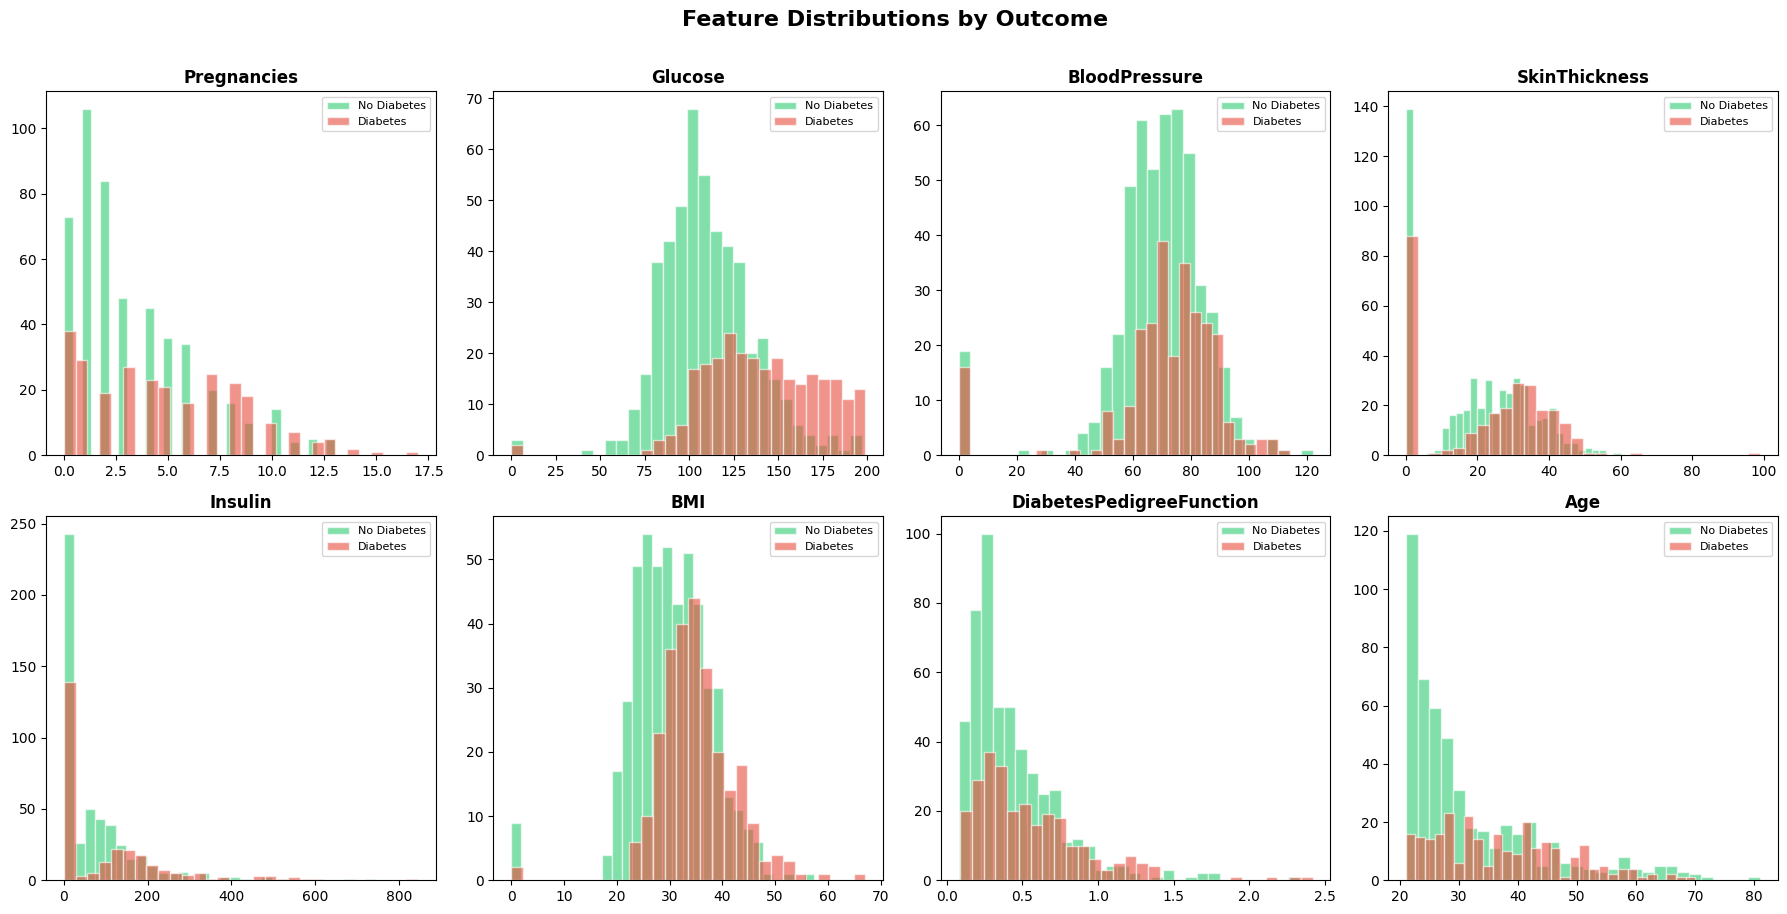

In [ ]:
# %% ─── CELL 5: Feature Distributions ────────────────────────
features = df.columns[:-1]  # all except Outcome

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    ax.hist(df[df["Outcome"] == 0][col], bins=30, alpha=0.6,
            label="No Diabetes", color="#2ecc71", edgecolor="white")
    ax.hist(df[df["Outcome"] == 1][col], bins=30, alpha=0.6,
            label="Diabetes", color="#e74c3c", edgecolor="white")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions by Outcome", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

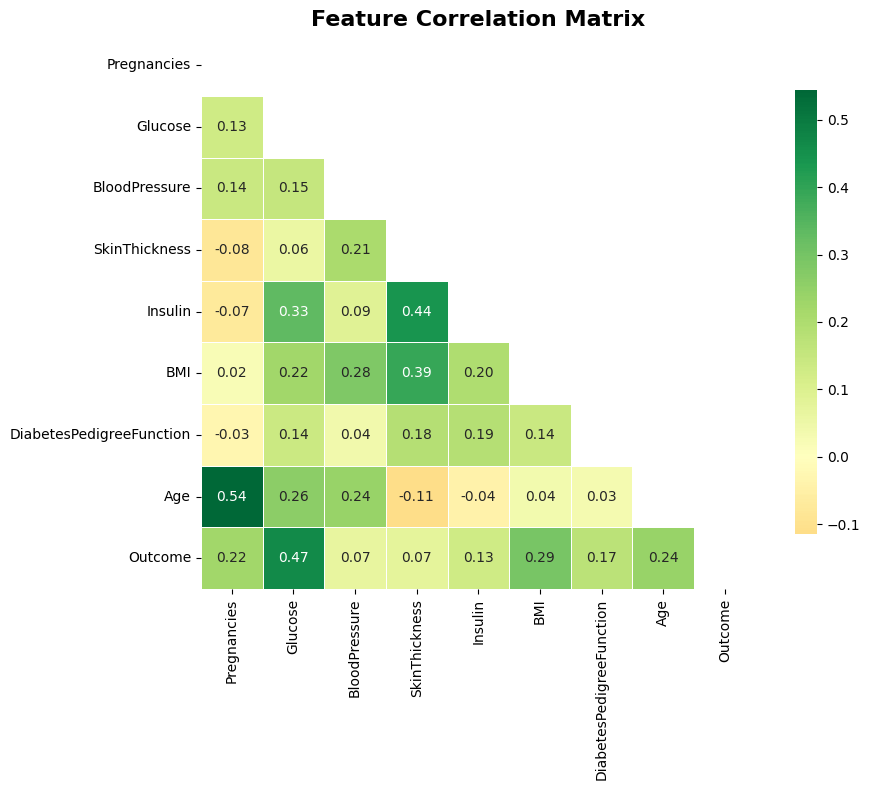

─── Correlation with Outcome ───
  Glucose                         +0.467  ██████████████████
  BMI                             +0.293  ███████████
  Age                             +0.238  █████████
  Pregnancies                     +0.222  ████████
  DiabetesPedigreeFunction        +0.174  ██████
  Insulin                         +0.131  █████
  SkinThickness                   +0.075  ██
  BloodPressure                   +0.065  ██


In [ ]:
# %% ─── CELL 6: Correlation Heatmap ──────────────────────────
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Top correlations with target
print("─── Correlation with Outcome ───")
target_corr = corr["Outcome"].drop("Outcome").sort_values(ascending=False)
for feat, val in target_corr.items():
    bar = "█" * int(abs(val) * 40)
    print(f"  {feat:30s}  {val:+.3f}  {bar}")

In [ ]:
# %% ─── CELL 7: Preprocess & Impute 0s with Median ───────────
# Columns where 0 is biologically impossible
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace 0s with NaN, then impute with column medians
df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)
df_clean[zero_cols] = df_clean[zero_cols].fillna(df_clean[zero_cols].median())

print("✅ Zeros imputed with column medians.")

✅ Zeros imputed with column medians.


In [ ]:
# %% ─── CELL 8: Simple Feature Engineering ──────────────────
# Create a single high-impact interaction feature (combining Blood Glucose and BMI)
df_clean["Glucose_BMI"] = df_clean["Glucose"] * df_clean["BMI"]

print("✅ Feature Engineering complete. Total features:", df_clean.shape[1] - 1)

✅ Feature Engineering complete. Total features: 9


In [ ]:
# %% ─── CELL 9: Train-Test Split & Scaling ───────────────────
# Separate features and target
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

# Stratified split to keep outcome ratio equal in train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training shapes: {X_train_scaled.shape}, {y_train.shape}")
print(f"Test shapes:     {X_test_scaled.shape}, {y_test.shape}")


Training shapes: (614, 9), (614,)
Test shapes:     (154, 9), (154,)


In [ ]:
# %% ─── CELL 10: Build Lightweight ANN Model ─────────────────
def build_optimized_ann(input_dim):
    """
    Lightweight model optimized for Pima Indians dataset.
    Features:
      - 16 -> 8 -> 1 architecture (prevents overfitting)
      - Batch Normalization on first layer to stabilize scaled input distributions
      - L2 Regularization to keep weights close to zero
      - Dropout to force redundant feature learning paths
    """
    model = Sequential([
        Input(shape=(input_dim,)),

        # Hidden Layer 1
        Dense(16, activation="relu", kernel_initializer="he_normal"),
        BatchNormalization(),
        Dropout(0.2),

        # Hidden Layer 2
        Dense(8, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.1),

        # Output Layer
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0015),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_optimized_ann(X_train_scaled.shape[1])
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 32 (128.00 B)

In [ ]:
# %% ─── CELL 11: Train the Model ─────────────────────────────
# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-5,
    verbose=1
)

print("🚀 Training starting...")
# Train with a standard validation split (15%) to avoid class weight bias
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.15,
    epochs=120,
    batch_size=16,  # Small batch sizes work better on Pima to escape local minima
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("✅ Training complete!")

🚀 Training starting...
Epoch 1/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.3647 - loss: 0.9431 - val_accuracy: 0.6989 - val_loss: 0.6632 - learning_rate: 0.0015
Epoch 2/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5067 - loss: 0.7725 - val_accuracy: 0.7634 - val_loss: 0.6002 - learning_rate: 0.0015
Epoch 3/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6315 - loss: 0.6656 - val_accuracy: 0.7527 - val_loss: 0.5570 - learning_rate: 0.0015
Epoch 4/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6967 - loss: 0.6248 - val_accuracy: 0.7419 - val_loss: 0.5258 - learning_rate: 0.0015
Epoch 5/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7236 - loss: 0.5983 - val_accuracy: 0.7742 - val_loss: 0.4984 - learning_rate: 0.0015
Epoch 6/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7294 - loss: 0.5741 - val_accuracy: 0.8065 - val_loss: 0.4766 - learning_rate: 0.0015
Epoch 7/120
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.744

In [ ]:
# %% ─── CELL 12: Train the Model ─────────────────────────────
# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=35,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-5,
    verbose=1
)

print("🚀 Training starting...")
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=16,
    class_weight=class_weight_dict,  # Apply weights to balance loss updates
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("✅ Training complete!")


🚀 Training starting...
Epoch 1/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.6196 - loss: 0.8469 - val_accuracy: 0.6290 - val_loss: 0.7032 - learning_rate: 0.0020
Epoch 2/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6993 - loss: 0.6784 - val_accuracy: 0.6935 - val_loss: 0.6249 - learning_rate: 0.0020
Epoch 3/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7120 - loss: 0.6150 - val_accuracy: 0.6290 - val_loss: 0.5879 - learning_rate: 0.0020
Epoch 4/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7246 - loss: 0.6112 - val_accuracy: 0.6774 - val_loss: 0.5693 - learning_rate: 0.0020
Epoch 5/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7446 - loss: 0.5890 - val_accuracy: 0.6774 - val_loss: 0.5588 - learning_rate: 0.0020
Epoch 6/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7409 - loss: 0.5767 - val_accuracy: 0.6774 - val_loss: 0.5532 - learning_rate: 0.0020
Epoch 7/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7554 

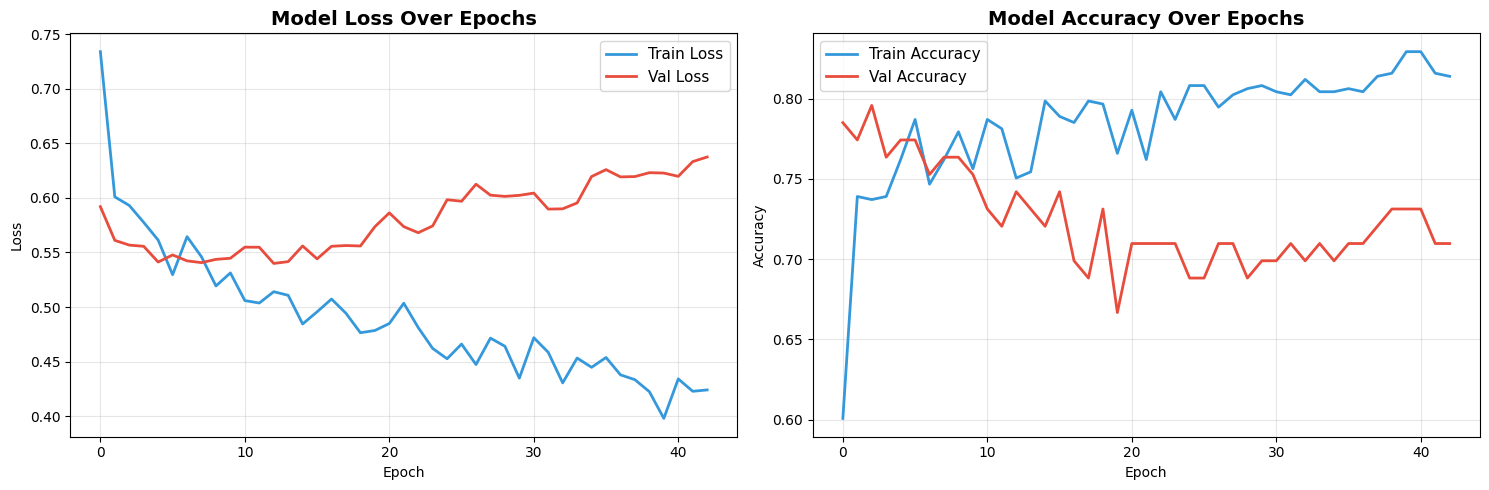

In [ ]:
# %% ─── CELL 13: Plot Training History ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history["loss"], label="Train Loss", color="#3498db", linewidth=2)
axes[0].plot(history.history["val_loss"], label="Val Loss", color="#e74c3c", linewidth=2)
axes[0].set_title("Model Loss Over Epochs", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history["accuracy"], label="Train Accuracy", color="#3498db", linewidth=2)
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy", color="#e74c3c", linewidth=2)
axes[1].set_title("Model Accuracy Over Epochs", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# %% ─── CELL 14: Evaluate on Test Set ────────────────────────
print("=" * 60)
print("📈  MODEL EVALUATION ON TEST SET")
print("=" * 60)

# Predictions
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Accuracy
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n  Test Accuracy:  {acc:.4f}  ({acc:.2%})")
print(f"  ROC-AUC Score:  {auc:.4f}")

print("\n─── Classification Report ───")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

📈  MODEL EVALUATION ON TEST SET
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

  Test Accuracy:  0.7078  (70.78%)
  ROC-AUC Score:  0.7994

─── Classification Report ───
              precision    recall  f1-score   support

 No Diabetes       0.77      0.79      0.78       100
    Diabetes       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



In [ ]:
!pip install -q kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
)

In [ ]:
# %% ─── CELL 2: Download & Load Dataset ──────────────────────
import kagglehub
import os

path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
print("Dataset downloaded to:", path)

csv_file = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith(".csv"):
            csv_file = os.path.join(root, f)
            break

print("CSV file found:", csv_file)
df = pd.read_csv(csv_file)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Dataset downloaded to: /kaggle/input/pima-indians-diabetes-database
CSV file found: /kaggle/input/pima-indians-diabetes-database/diabetes.csv


In [ ]:
# %% ─── CELL 7: Train-Test Split (BEFORE Imputation) ────────
# To avoid data leakage, we split the data BEFORE imputing missing values or scaling.
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Stratified split to keep outcome ratio equal in train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# %% ─── CELL 8: KNN Imputation for Missing Values (Zeros) ───
# Columns where 0 is biologically impossible
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace 0s with NaN
X_train_nan = X_train.copy()
X_test_nan = X_test.copy()
X_train_nan[zero_cols] = X_train_nan[zero_cols].replace(0, np.nan)
X_test_nan[zero_cols] = X_test_nan[zero_cols].replace(0, np.nan)

# Use KNN Imputer (predicts missing values based on similar patients)
# This is much cleaner than flat medians and maintains feature relationships
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_nan), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_nan), columns=X_test.columns)

print("✅ KNN Imputation completed. No NaNs remain.")


# %% ─── CELL 9: Medical Feature Engineering ─────────────────
# Creating high-value interaction features to help the ANN learn non-linear boundaries:
# 1. Glucose & BMI interaction (high values for both indicates severe risk)
X_train_imputed["Glucose_BMI"] = X_train_imputed["Glucose"] * X_train_imputed["BMI"]
X_test_imputed["Glucose_BMI"] = X_test_imputed["Glucose"] * X_test_imputed["BMI"]

# 2. Age & Pregnancies interaction (risk changes with age + pregnancies combination)
X_train_imputed["Age_Pregnancies"] = X_train_imputed["Age"] * X_train_imputed["Pregnancies"]
X_test_imputed["Age_Pregnancies"] = X_test_imputed["Age"] * X_test_imputed["Pregnancies"]

# 3. Insulin Resistance Proxy (Insulin / Glucose relationship)
X_train_imputed["Insulin_Glucose_Ratio"] = X_train_imputed["Insulin"] / (X_train_imputed["Glucose"] + 1e-5)
X_test_imputed["Insulin_Glucose_Ratio"] = X_test_imputed["Insulin"] / (X_test_imputed["Glucose"] + 1e-5)

print("✅ Feature Engineering complete. Total features:", X_train_imputed.shape[1])


# %% ─── CELL 10: Scale Features & Prepare Validation Set ────
# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Split training set into Train & Validation using a stratified split.
# This prevents Keras val_split target mismatch and provides stable validation metrics.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# Calculate Class Weights to handle dataset imbalance (65% / 35%)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_tr),
    y=y_tr
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print(f"Training shapes:   {X_tr.shape}, {y_tr.shape}")
print(f"Validation shapes: {X_val.shape}, {y_val.shape}")
print(f"Test shapes:       {X_test_scaled.shape}, {y_test.shape}")
print(f"Class weights:     {class_weight_dict}")


# %% ─── CELL 11: Build Optimized ANN Model ───────────────────
def build_optimized_ann(input_dim):
    """
    An optimized, regularized ANN model for tabular classification.
    Uses L2 regularization to prevent overfitting on the small dataset.
    """
    model = Sequential([
        Input(shape=(input_dim,)),

        # Hidden Layer 1
        Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.002)),
        BatchNormalization(),
        Dropout(0.2),

        # Hidden Layer 2
        Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.002)),
        BatchNormalization(),
        Dropout(0.2),

        # Output Layer
        Dense(1, activation="sigmoid")
    ])

    # Using Adam with a slightly higher starting learning rate
    model.compile(
        optimizer=Adam(learning_rate=0.005),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_optimized_ann(X_train_scaled.shape[1])
model.summary()


# %% ─── CELL 12: Train the Model ─────────────────────────────
# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-5,
    verbose=1
)

print("🚀 Training starting...")
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weight_dict,  # Apply weights to balance loss updates
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("✅ Training complete!")







✅ KNN Imputation completed. No NaNs remain.
✅ Feature Engineering complete. Total features: 11
Training shapes:   (521, 11), (521,)
Validation shapes: (93, 11), (93,)
Test shapes:       (154, 11), (154,)
Class weights:     {0: np.float64(0.7684365781710915), 1: np.float64(1.4313186813186813)}


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 96 (384.00 B)

🚀 Training starting...
Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step - accuracy: 0.6315 - loss: 0.7891 - val_accuracy: 0.6667 - val_loss: 0.6666 - learning_rate: 0.0050
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7198 - loss: 0.6454 - val_accuracy: 0.7419 - val_loss: 0.6211 - learning_rate: 0.0050
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7274 - loss: 0.5890 - val_accuracy: 0.7957 - val_loss: 0.5974 - learning_rate: 0.0050
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7332 - loss: 0.5887 - val_accuracy: 0.7849 - val_loss: 0.5812 - learning_rate: 0.0050
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7505 - loss: 0.5705 - val_accuracy: 0.7957 - val_loss: 0.5798 - learning_rate: 0.0050
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7582 - loss: 0.5545 - val_accuracy: 0.7742 - val_loss: 0.5686 - learning_rate: 0.0050
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7774

In [ ]:
# %% ─── CELL 14: Evaluate on Test Set ────────────────────────
print("=" * 60)
print("📈  MODEL EVALUATION ON TEST SET")
print("=" * 60)

# Predictions
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Accuracy
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"\n  Test Accuracy:  {acc:.4f}  ({acc:.2%})")
print(f"  ROC-AUC Score:  {auc:.4f}")

print("\n─── Classification Report ───")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

📈  MODEL EVALUATION ON TEST SET
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

  Test Accuracy:  0.7597  (75.97%)
  ROC-AUC Score:  0.8143

─── Classification Report ───
              precision    recall  f1-score   support

 No Diabetes       0.81      0.82      0.82       100
    Diabetes       0.66      0.65      0.65        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.76      0.76       154



In [ ]:
# %% ─── CELL 17: Save the Trained Model & Pipeline ───────────
import joblib

# Save model in both formats
model.save("diabetes_ann_model.h5")
model.save("diabetes_ann_model.keras")

# Save scaler and imputer so we can reconstruct the pipeline in the API
joblib.dump(scaler, "scaler.joblib")
joblib.dump(imputer, "imputer.joblib")

print("✅ Saved files:")
for f in ["diabetes_ann_model.h5", "diabetes_ann_model.keras", "scaler.joblib", "imputer.joblib"]:
    print(f"   • {f}")

✅ Saved files:
   • diabetes_ann_model.h5
   • diabetes_ann_model.keras
   • scaler.joblib
   • imputer.joblib
